In [20]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

sigma, b = 1e-3, 5

nodi, L = 100, 1  # n di nodi spaziali
m, T = 2000, 11  # dt = 0.15

h = L / nodi  # passo spaziale 
tau = T / m


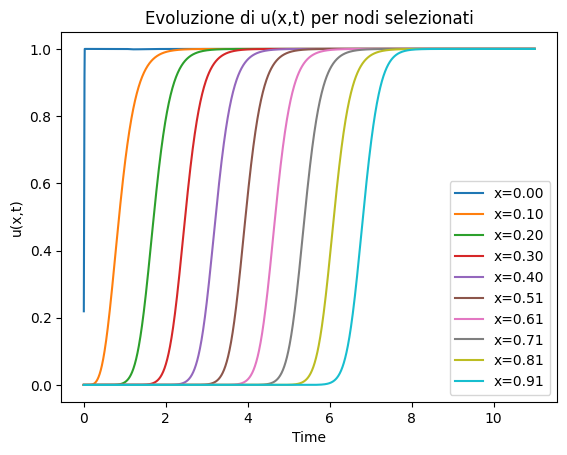

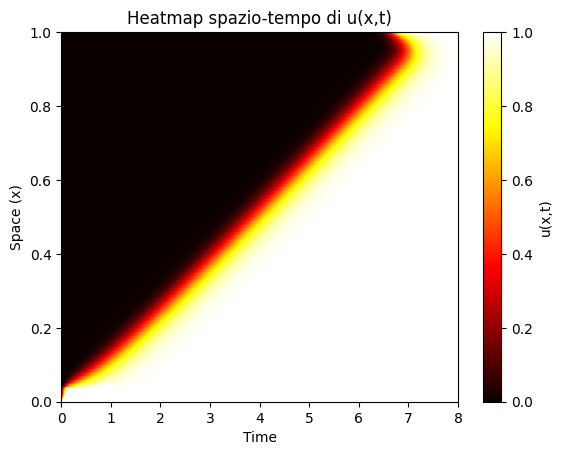

In [21]:

x = np.linspace(0, L, nodi)
t  = np.linspace(0, T, m)

u= np.zeros(nodi)
u_new = np.zeros(nodi)

# A matrix con Newuman cond
A = 2 * np.diag(np.ones(nodi)) - np.diag(np.ones(nodi - 1), 1) - np.diag(np.ones(nodi - 1), -1)
A[0, 0] = A[-1, -1] = 1 
A[0, 1] = A[-1, -2] = -1
A = A* (sigma / h**2)

M = np.eye(nodi)
M[0, 0] = M[-1, -1] = 1 / 2
M [0, 1] = M[-1, -2] = -1

J = M/tau + A # coeff di u^k+1 della discretizzazione implicita 

Iap = 10
iapp = np.zeros(nodi)    # passi del sistema 
iapp[x <= 0.04] = Iap  # Stimolo nella regione [0, 0.04]


# Simulazione nel tempo
t0 = 0
time = []
results = []

# dynamic graph
plt.ion()
plot_interval = T / 13  # ridurre il numero di grafici
next_plot_time = 0

while t0 <= T:
    t0 += tau
    i = np.zeros(nodi)

    if t0 <= 1:         ## CONdizioni nel tempo
        i += iapp  # aggiungo stimolo iniziale 
    i +=  b * u * (1 - u) 
     # termine non lineare  + corrente messa al passo prima #Per valori piccoli di uu, il termine cresce velocemente, ma quando u→1u→1, si stabilizza.
    RHS = M @ ( u/ tau ) + i   # uu == soluzione u in t = k 

    u_new  = np.linalg.solve(J, RHS)
    u = np.clip(u_new, 0, 1)
    #print(f"Time: {t0:.2f}, Max u: {np.max(u)}, Min u: {np.min(u)}")

# ----------------------------

    # real time plot 
    results.append(u.copy())
    time.append(t0)


results = np.array(results)

plt.ioff() 

plt.figure(1)
for i in range(0, nodi, 10):  # Prendi nodi ogni 10
    plt.plot(time, results[:, i], label=f"x={x[i]:.2f}")
plt.xlabel("Time")
plt.ylabel("u(x,t)")
plt.title("Evoluzione di u(x,t) per nodi selezionati")
plt.legend()
plt.show()

# Grafico 2: Heatmap spazio-tempo
plt.figure(2)
plt.imshow(results.T, extent=[0, T, 0, L], origin="lower", aspect="auto", cmap="hot")
plt.colorbar(label="u(x,t)")
plt.xlabel("Time")
plt.ylabel("Space (x)")
plt.xlim(0,8)
plt.title("Heatmap spazio-tempo di u(x,t)")
plt.show() 

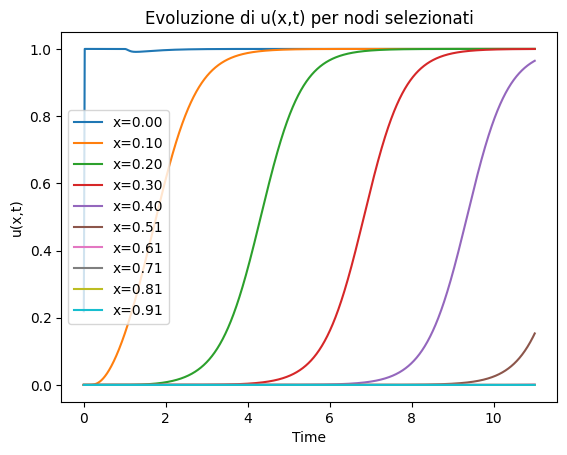

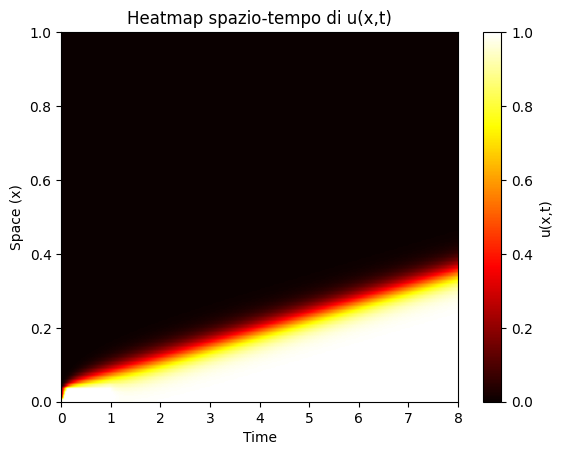

In [22]:

### same for NAGUMO

x = np.linspace(0, L, nodi)
t  = np.linspace(0, T, m)

u= np.zeros(nodi)
u_new = np.zeros(nodi)

# A matrix con Newuman cond
A = 2 * np.diag(np.ones(nodi)) - np.diag(np.ones(nodi - 1), 1) - np.diag(np.ones(nodi - 1), -1)
A[0, 0] = A[-1, -1] = 1 
A[0, 1] = A[-1, -2] = -1
A = A* (sigma / h**2)

M = np.eye(nodi)
M[0, 0] = M[-1, -1] = 1 / 2
M [0, 1] = M[-1, -2] = -1

J = M/tau + A # coeff di u^k+1 della discretizzazione implicita 

Iap = 10
iapp = np.zeros(nodi)    # passi del sistema 
iapp[x <= 0.04] = Iap  # Stimolo nella regione [0, 0.04]


# Simulazione nel tempo
t0 = 0
time = []
results = []

beta, delta = 0.1, 1

while t0 <= T:
    t0 += tau
    i = np.zeros(nodi)

    if t0 <= 1:         ## CONdizioni nel tempo
        i += iapp  # aggiungo stimolo iniziale 
    i +=  b * u * (u - beta) * (delta - u) 
     # termine non lineare  + corrente messa al passo prima #Per valori piccoli di uu, il termine cresce velocemente, ma quando u→1u→1, si stabilizza.
    RHS = M @ ( u/ tau ) + i   # uu == soluzione u in t = k 

    u_new  = np.linalg.solve(J, RHS)
    u = np.clip(u_new, 0, 1)
    #print(f"Time: {t0:.2f}, Max u: {np.max(u)}, Min u: {np.min(u)}")

# ----------------------------

    # real time plot 
    results.append(u.copy())
    time.append(t0)


results = np.array(results)


plt.ioff() 

plt.figure(1)
for i in range(0, nodi, 10):  # Prendi nodi ogni 10
    plt.plot(time, results[:, i], label=f"x={x[i]:.2f}")
plt.xlabel("Time")
plt.ylabel("u(x,t)")
plt.title("Evoluzione di u(x,t) per nodi selezionati")
plt.legend()
plt.show()

# Grafico 2: Heatmap spazio-tempo
plt.figure(2)
plt.imshow(results.T, extent=[0, T, 0, L], origin="lower", aspect="auto", cmap="hot")
plt.colorbar(label="u(x,t)")
plt.xlabel("Time")
plt.ylabel("Space (x)")
plt.xlim(0,8)
plt.title("Heatmap spazio-tempo di u(x,t)")
plt.show() 

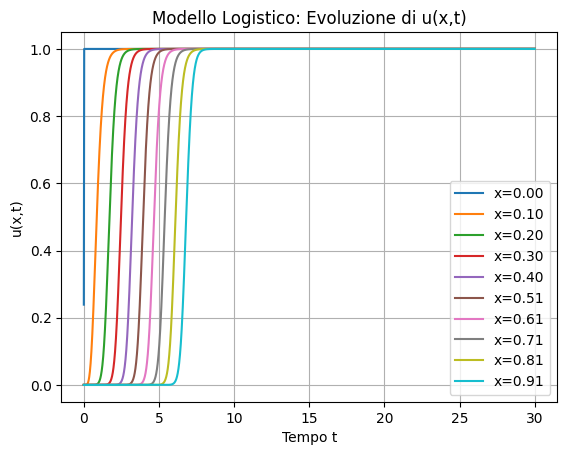

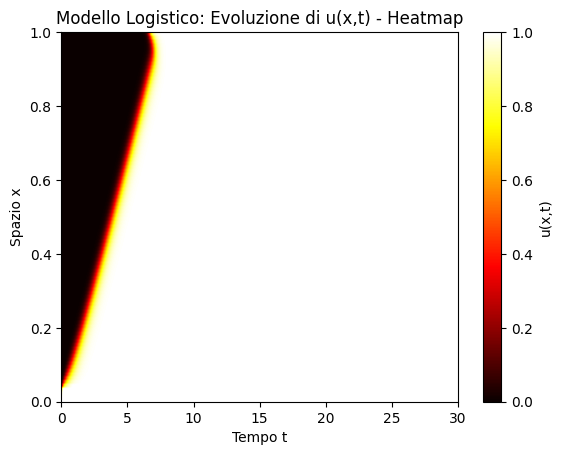

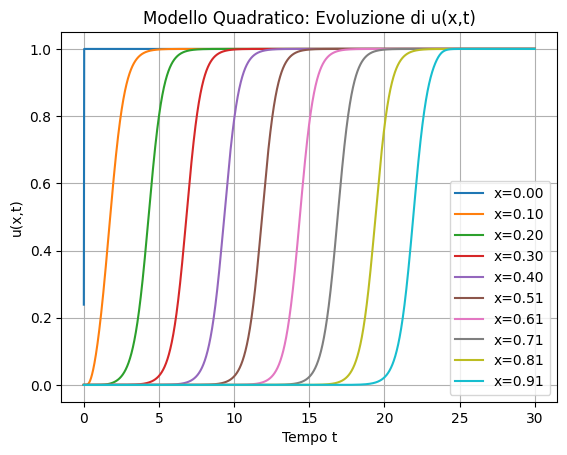

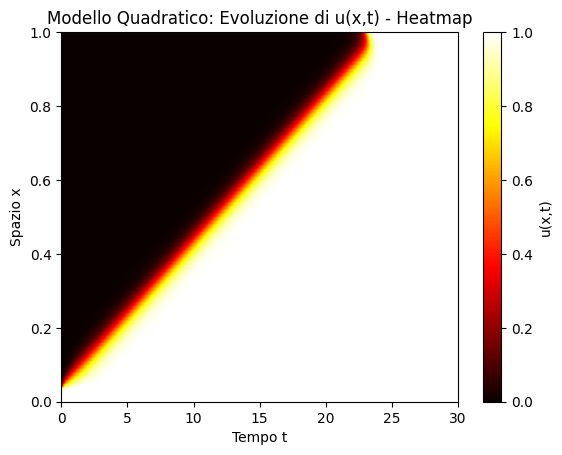

In [23]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

# -------------------------
# ⚙️ PARAMETRI GLOBALI
# -------------------------
sigma, b = 1e-3, 5  
nodi, L = 100, 1  
m, T = 5000, 30  
h = L / nodi  
tau = T / m  

# Matrice spaziale A con condizioni di Neumann
A = 2 * np.diag(np.ones(nodi)) - np.diag(np.ones(nodi - 1), 1) - np.diag(np.ones(nodi - 1), -1)
A[0, 0] = A[-1, -1] = 1  
A[0, 1] = A[-1, -2] = -1
A = A * (sigma / h**2)

# Matrice temporale M
M = np.eye(nodi)
M[0, 0] = M[-1, -1] = 1 / 2
M[0, 1] = M[-1, -2] = -1

# Matrice del sistema J
J = M / tau + A  

# Stimolo applicato
Iap = 10
iapp = np.zeros(nodi)    
iapp[:int(0.04 * nodi)] = Iap  



def F1(u):
    return b * u * (1 - u)


def F2(u):
    return b * u* (u - beta) * (delta - u)



def simulate(F_func, title="Evoluzione di u(x,t)"):
    """
    Esegue la simulazione per una data funzione di reazione F_func.
    """
    u = np.zeros(nodi)  
    t0 = 0
    time = []
    results = []

    while t0 <= T:
        t0 += tau
        i = np.zeros(nodi)

        if t0 <= 5:  # Stimolo nei primi secondi
            i += iapp  

        # Calcolo del termine non lineare
        F = F_func(u)  

        # Costruzione del RHS e soluzione del sistema
        RHS = M @ (u / tau) + i + F  
        u_new = np.linalg.solve(J, RHS)
        u = np.clip(u_new, 0, 1)

        results.append(u.copy())
        time.append(t0)

    results = np.array(results)

    plt.figure()
    for i in range(0, nodi, 10):  
        plt.plot(time, results[:, i], label=f"x={x[i]:.2f}")
    plt.xlabel("Tempo t")
    plt.ylabel("u(x,t)")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure()
    plt.imshow(results.T, extent=[0, T, 0, L], origin="lower", aspect="auto", cmap="hot")
    plt.colorbar(label="u(x,t)")
    plt.xlabel("Tempo t")
    plt.ylabel("Spazio x")
    plt.title(title + " - Heatmap")
    plt.show()

simulate(F1, title="Modello Logistico: Evoluzione di u(x,t)")
simulate(F2, title="Modello Quadratico: Evoluzione di u(x,t)")
